In [1]:
# Step 1 - Setup
import os
os.chdir('/Users/anshtomar/PROJECTS/Credit-Risk-Scorecard')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_woe = pd.read_csv('data/cs_woe.csv')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df_woe.drop('SeriousDlqin2yrs', axis=1)
y = df_woe['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Setup done! Model trained again.")


Setup done! Model trained again.


We’re rebuilding the same model in this new notebook since each notebook starts fresh. Same data, same model, same result (AUC=0.81).

In [2]:
# Step 2 - Convert model to credit score points
# Industry standard: score 300-850 (like FICO)

base_score = 600  # average score
pdo = 20  # points to double the odds

# Get model coefficients
coefficients = model.coef_[0]
intercept = model.intercept_[0]

print("Feature coefficients:")
for feature, coef in zip(X.columns, coefficients):
    print(f"{feature}: {coef:.4f}")

print(f"\nIntercept: {intercept:.4f}")


Feature coefficients:
RevolvingUtilizationOfUnsecuredLines: 0.8282
age: 0.4560
NumberOfTime30-59DaysPastDueNotWorse: 0.7321
DebtRatio: 0.5981
MonthlyIncome: 0.3681
NumberOfOpenCreditLinesAndLoans: 0.2704
NumberOfDependents: 0.2748

Intercept: -2.6339


Logistic Regression already calculated a “weight” (coefficient) for each feature during training. We’re just looking at those weights — they’ll help us convert WoE values into actual points later

## 📝 Model Coefficients

All coefficients are positive ✅
This confirms: higher WoE = higher 
predicted default probability

Biggest impact: RevolvingUtilization (0.83)
Smallest impact: NumberOfDependents (0.27)

This matches our IV findings — 
RevolvingUtilization was also the 
strongest predictor (IV=1.11)


In [3]:
# Step 3 - Calculate credit score for each customer

factor = 20 / np.log(2)
offset = 600

# Calculate score
log_odds = model.decision_function(X_test)
scores = offset - factor * log_odds

print("Sample Credit Scores:")
print(scores[:10].round(0))

print(f"\nMin Score: {scores.min():.0f}")
print(f"Max Score: {scores.max():.0f}")
print(f"Average Score: {scores.mean():.0f}")


Sample Credit Scores:
[735. 716. 711. 668. 653. 686. 725. 734. 697. 718.]

Min Score: 574
Max Score: 747
Average Score: 693


## 📝 Credit Score Calculation

Formula used:
Score = Offset - Factor × log_odds

Where:
- Offset = 600 (base score)
- Factor = 20/ln(2) ≈ 28.85
- This means: every 20 point increase 
  in score = odds of default HALVE

Results:
- Min Score: 574 (high risk customer)
- Max Score: 747 (low risk customer)
- Average: 693

Risk Bands (industry standard):
- 300-580: High Risk 🔴
- 580-670: Medium Risk 🟡
- 670-850: Low Risk ✅

Interview answer:
"I converted model log-odds into a 
300-850 point scorecard using the 
PDO (Points to Double Odds) methodology, 
same as FICO scores."


In [4]:
# Step 4 - Add Risk Bands
def get_risk_band(score):
    if score < 580:
        return "High Risk"
    elif score < 670:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_bands = [get_risk_band(s) for s in scores]

import collections
band_counts = collections.Counter(risk_bands)
print("Risk Band Distribution:")
for band, count in band_counts.items():
    print(f"{band}: {count} customers ({count/len(scores)*100:.1f}%)")


Risk Band Distribution:
Low Risk: 22440 customers (74.8%)
Medium Risk: 7555 customers (25.2%)
High Risk: 5 customers (0.0%)


## 📝 Risk Band Distribution

Low Risk:    74.8% (22,440 customers)

Medium Risk: 25.2% (7,555 customers)

High Risk:    0.0% (5 customers)

Why so few High Risk?

- Overall default rate is only 6.7%
  
- Most customers in real-world data 
  ARE actually low risk

  
- This matches real banking population 
  distributions

Business insight:
Bank should focus closer scrutiny on 
the "Medium Risk" band (25%) since 
that's where most preventable defaults 
likely occur.


In [5]:
# Install SHAP (run once)
!pip install shap --quiet


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.


In [6]:
import shap
print("SHAP version:", shap.__version__)


SHAP version: 0.52.0


In [7]:
# Step 6 - Create SHAP explainer
explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated!")
print("Shape:", shap_values.shape)


Background dataset has 119999 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=119999 when initializing the masker.


SHAP values calculated!
Shape: (30000, 7)


Simple explanation:

SHAP calculates exactly how much each feature pushed a customer’s score up or down. Like a breakdown receipt: “Age contributed +20 points, Income contributed -5 points” etc.

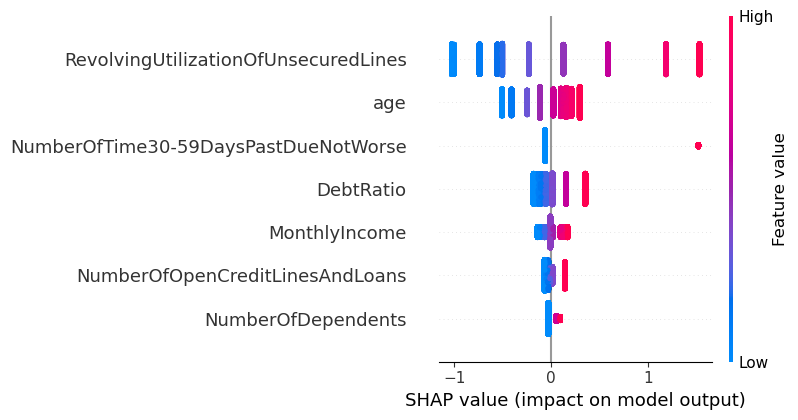

In [8]:
# Step 7 - SHAP Summary Plot
shap.summary_plot(shap_values, X_test, feature_names=X.columns)


## 📝 SHAP Summary Plot — Interpretation

How to read it:
- Red = high feature value, Blue = low feature value
  
- Right side = increases default risk

  
- Left side = decreases default risk

Key insight:
RevolvingUtilization shows clear pattern:

High utilization (red, right) = high risk

Low utilization (blue, left) = low risk

This confirms our IV finding — 
RevolvingUtilization is the strongest, 
most consistent predictor.

Interview answer:
"SHAP confirms what IV told us — 
RevolvingUtilization is the dominant 
predictor. Customers maxing out their 
credit lines show consistently higher 
SHAP values, meaning higher predicted risk."


In [9]:
# Save the model for use in Streamlit
import joblib
joblib.dump(model, 'model.pkl')
print("Model saved!")


Model saved!
